<a href="https://colab.research.google.com/github/Constellation-Nyx/Demo/blob/main/Stock_Prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Stock Price Prediction using Linear Regression


This project performs regression analysis on stock data to predict stock prices.

It includes data loading, cleaning, EDA, visualization, model training, and evaluation.


In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
import plotly.graph_objects as go

plt.style.use("seaborn-v0_8-whitegrid")


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving StockData.csv to StockData.csv


In [ ]:
df = pd.read_csv("StockData.csv")

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


✅ Dataset loaded successfully!
Shape: (1258, 14)

Columns: ['symbol', 'date', 'close', 'high', 'low', 'open', 'volume', 'adjClose', 'adjHigh', 'adjLow', 'adjOpen', 'adjVolume', 'divCash', 'splitFactor']


,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,########,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0,1
1,GOOG,########,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0,1
2,GOOG,########,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0,1
3,GOOG,########,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0,1
4,GOOG,########,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0,1


###Data Cleaning and Preprocessing

In [ ]:
df = df.drop(columns=['date'], errors='ignore')
print("Missing values:\n", df.isnull().sum())

duplicates=df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicates}" )

null_values=df.isnull().values.any()
print(f"Are there any null values? {null_values}")

df.info()


Missing values:
 symbol         0
close          0
high           0
low            0
open           0
volume         0
adjClose       0
adjHigh        0
adjLow         0
adjOpen        0
adjVolume      0
divCash        0
splitFactor    0
dtype: int64
Number of Duplicate Rows: 0
Are there any null values? False
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   close        1258 non-null   float64
 2   high         1258 non-null   float64
 3   low          1258 non-null   float64
 4   open         1258 non-null   float64
 5   volume       1258 non-null   int64  
 6   adjClose     1258 non-null   float64
 7   adjHigh      1258 non-null   float64
 8   adjLow       1258 non-null   float64
 9   adjOpen      1258 non-null   float64
 10  adjVolume    1258 non-null   int64  
 11  divCash      1258 non-null   i

###Exploratory Data Analysis (EDA)


             close         high          low         open        volume  \
count  1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03   
mean   1216.317067  1227.430935  1204.176430  1215.260778  1.601590e+06   
std     383.333358   387.570874   378.777095   382.446995  6.960172e+05   
min     668.260000   672.300000   663.284000   671.000000  3.467530e+05   
25%     960.802500   968.757500   952.182500   959.005000  1.173522e+06   
50%    1132.460000  1143.935000  1117.915000  1131.150000  1.412588e+06   
75%    1360.595000  1374.345000  1348.557500  1361.075000  1.812156e+06   
max    2521.600000  2526.990000  2498.290000  2524.920000  6.207027e+06   

          adjClose      adjHigh       adjLow      adjOpen     adjVolume  \
count  1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03   
mean   1216.317067  1227.430937  1204.176437  1215.260778  1.601590e+06   
std     383.333358   387.570876   378.777100   382.446995  6.960172e+05   
min     668.260000   672

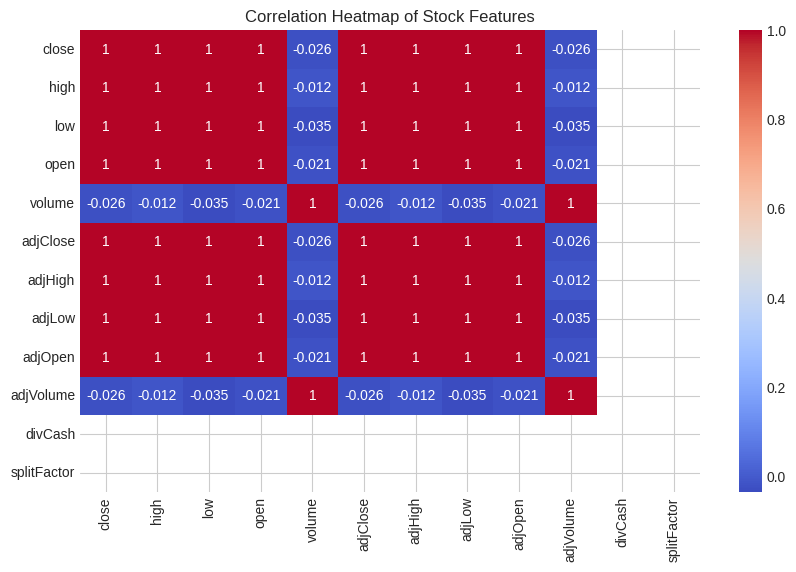

<Axes: >

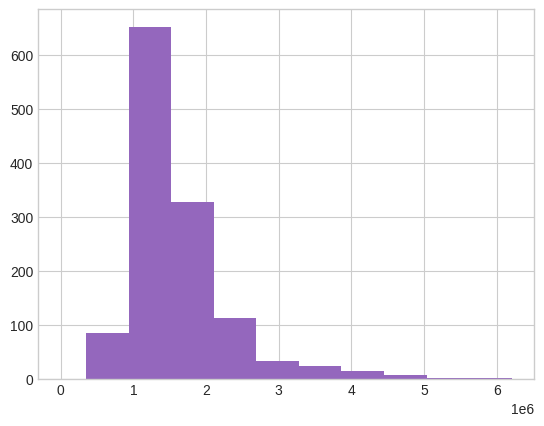

In [ ]:
print(df.describe())
correlations = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlations, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Stock Features")
plt.show()

#plot histograms for each variable
df['open'].hist()
df['high'].hist()
df['low'].hist()
df['close'].hist()
df['volume'].hist()



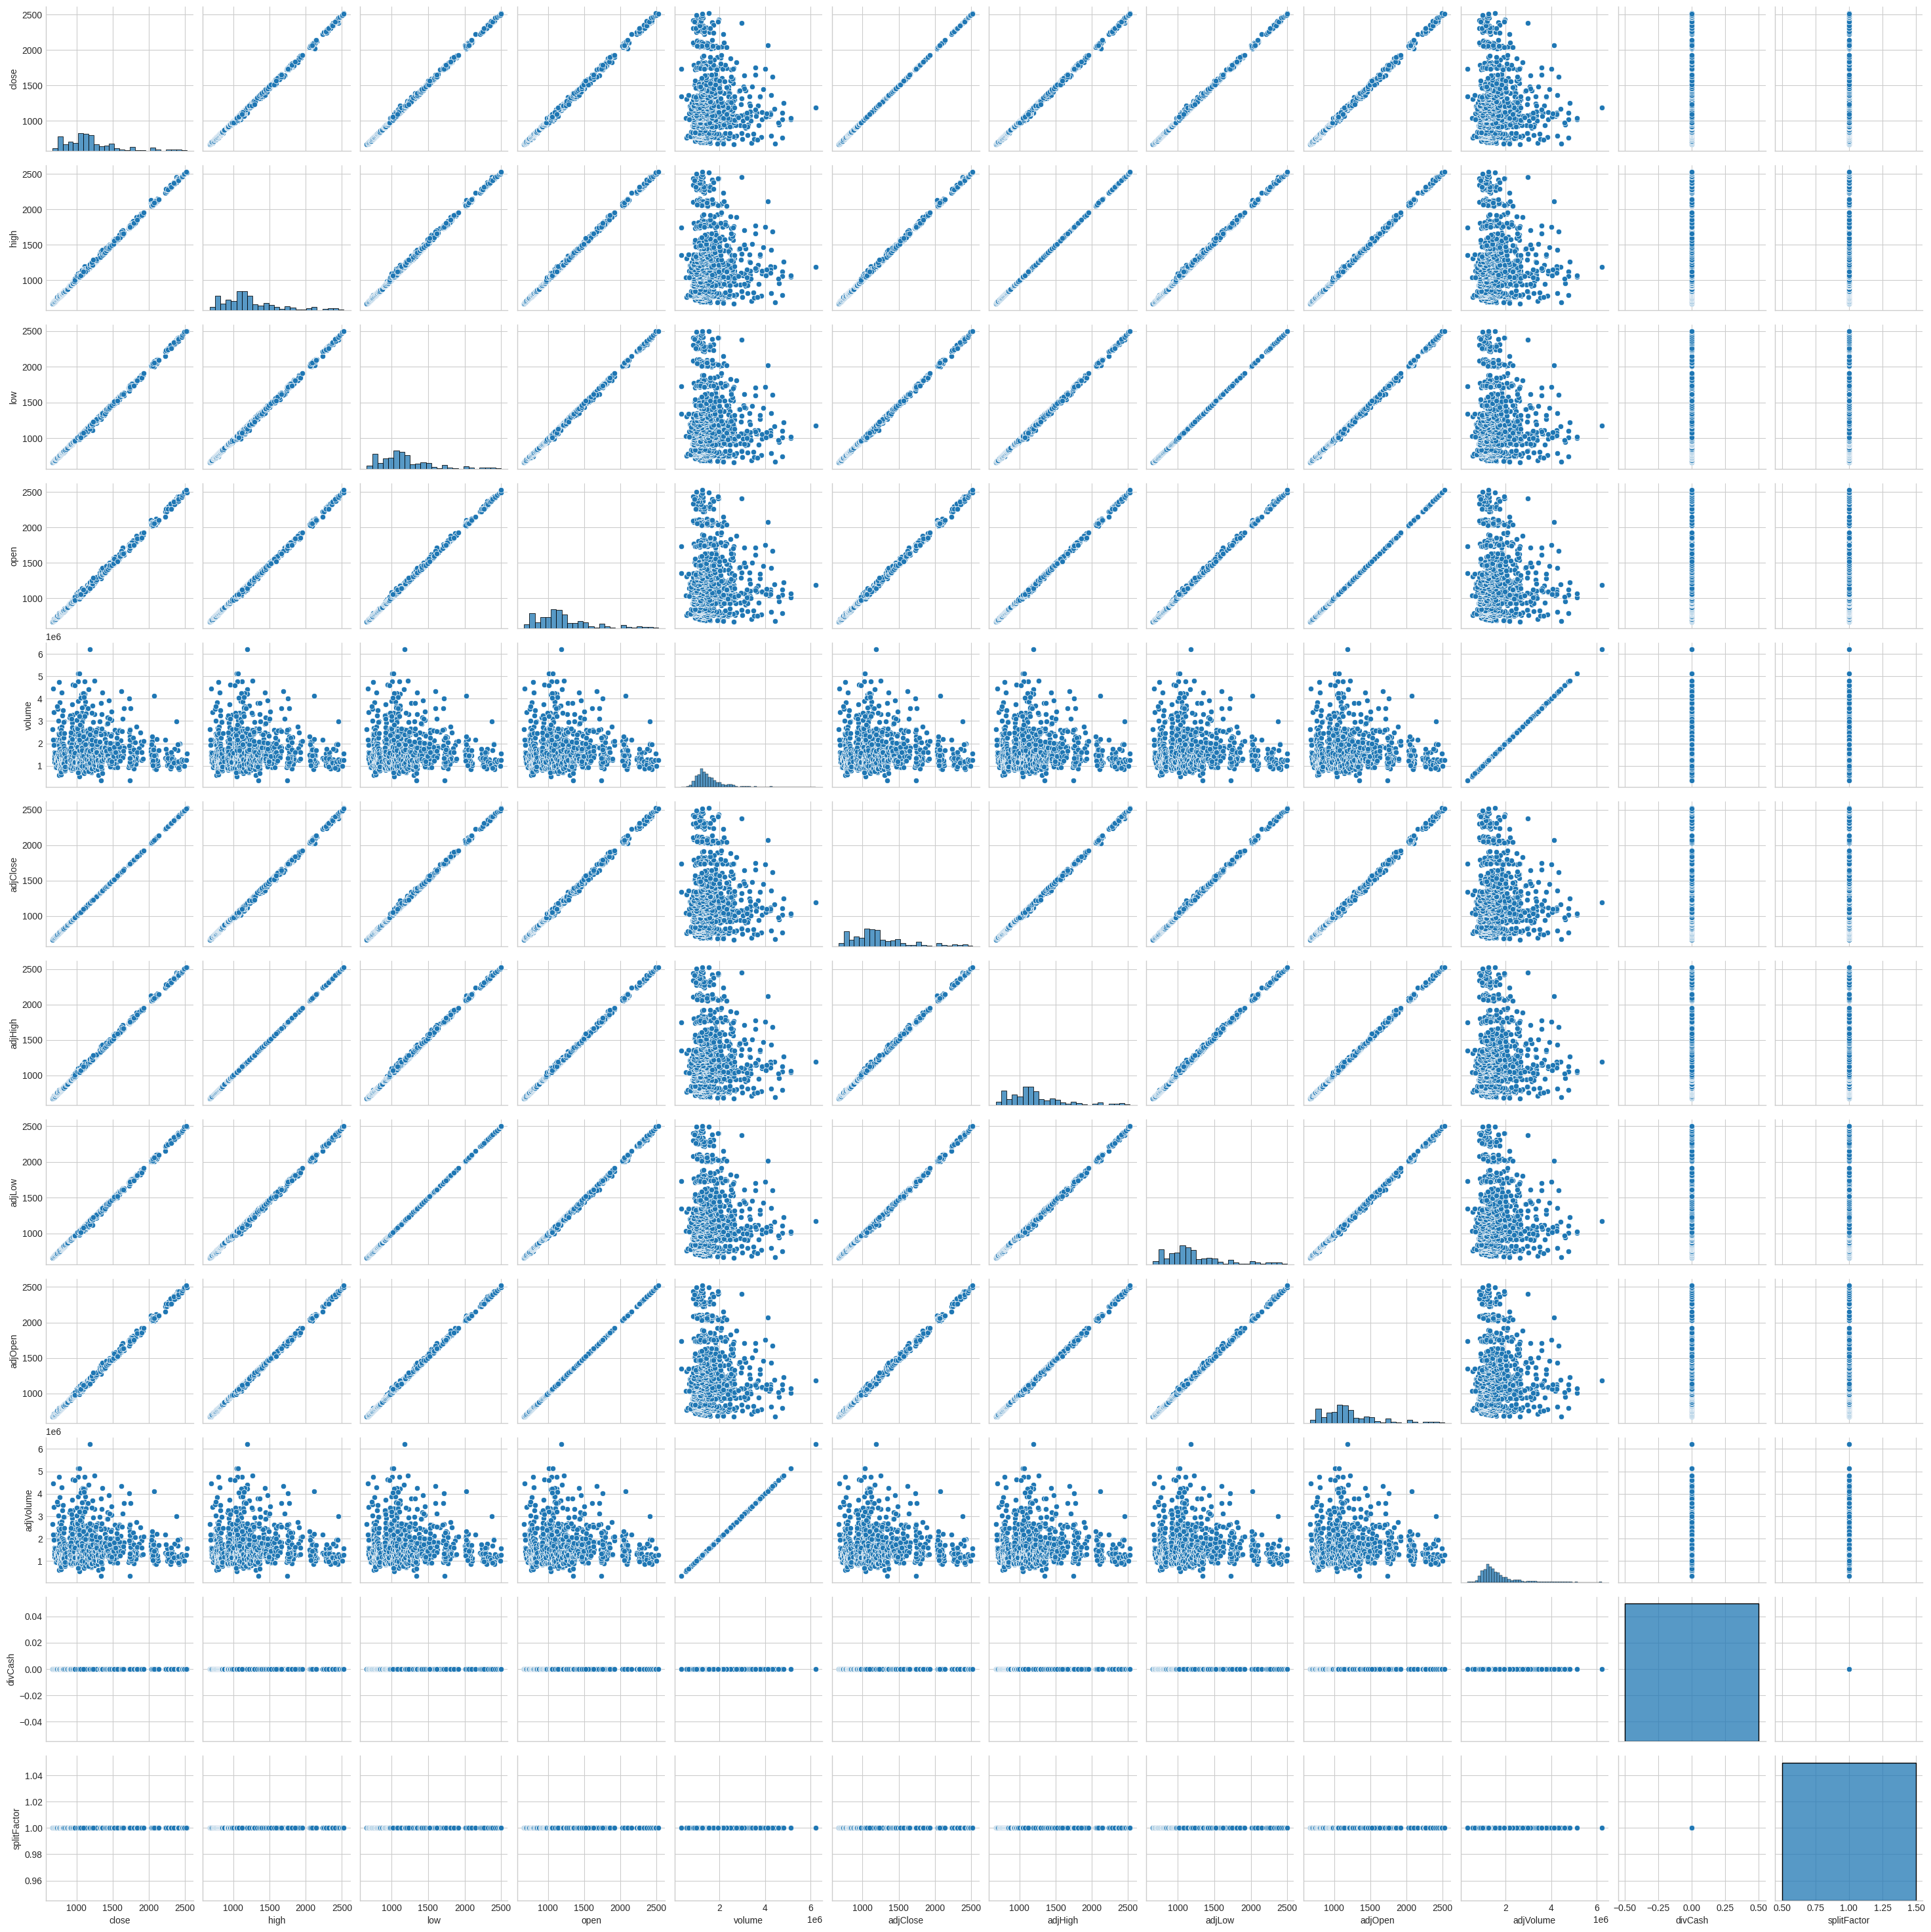

In [ ]:
#Visualize relationships using pair plots
sns.pairplot(df)

####Visualize Stock Price Trend


In [ ]:
figure = go.Figure(data=[go.Candlestick(x=df.index,
                                       open=df['open'],
                                       high=df['high'],
                                       low=df['low'],
                                       close=df['close'])])
figure.update_layout(title="Google Stock Price Analysis",
                     xaxis_rangeslider_visible=False)
figure.show()

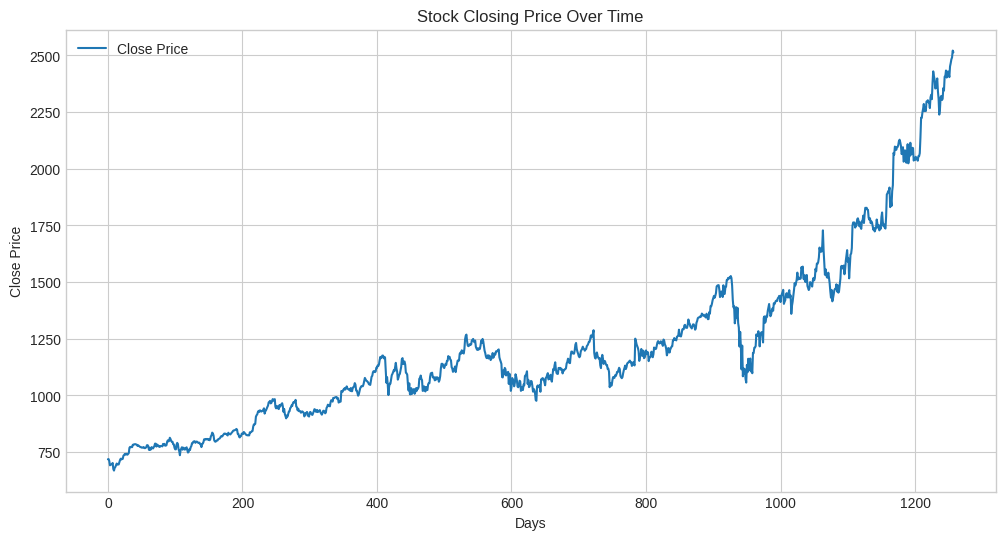

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['close'], label='Close Price')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.legend()
plt.show()


###Split dataset into Training and Testing

In [ ]:
X = df[['open', 'high', 'low', 'volume']].values
y = df['close'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

print("Model trained successfully!")


Train: (1006, 4)
Test: (252, 4)
✅ Model trained successfully!


###Train Linear Regression Model

In [ ]:
# Create and train the linear regression model
regressor= LinearRegression()
regressor.fit(X_train, y_train)

#Make predictions on the test data
y_pred= regressor.predict(X_test)

# Display model coefficients and intercept
print("Model Coefficients:", regressor.coef_)
print("Model Intercept:", regressor.intercept_)


Model Coefficients: [-5.54784360e-01  7.77461486e-01  7.76834243e-01 -4.55054752e-07]
Model Intercept: 1.4776019862770227


###Evaluate Model Performance

In [ ]:
# Create a DataFrame to compare actual and predicted values
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred.shape)
df_results = pd.DataFrame({'Actual': y_test.ravel(), 'Predicted': y_pred.ravel()})
print(df_results.head())

# Calculate evaluation metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

Shape of y_test: (252,)
Shape of y_pred: (252,)
    Actual    Predicted
0   695.94   697.302935
1  1084.99  1090.146796
2   769.54   772.628263
3  1349.33  1345.790923
4   843.25   841.900955
Mean Absolute Error: 5.170018928527545
Mean Squared Error: 51.25247167592226
Root Mean Squared Error: 7.159083158891385


###Analyze Residuals

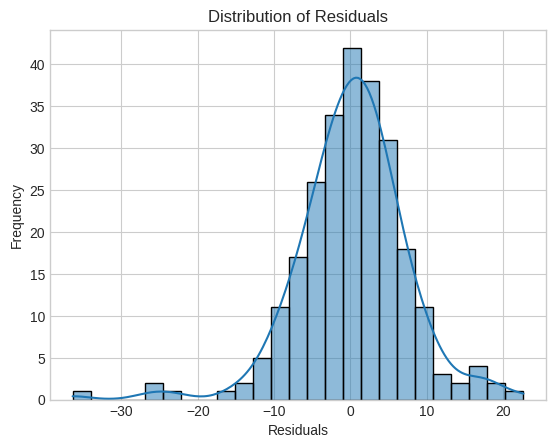

P-value: 0.04745968180294733


In [ ]:
# Calculate residuals
residuals = y_test- y_pred
# Visualize the distribution of residuals
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()
# Perform a p-value calculation
p_value = stats.norm.sf(abs(1.67))
print(f"P-value: {p_value}")

###Model Accuracy and Visualisation

Model Accuracy: 99.59%


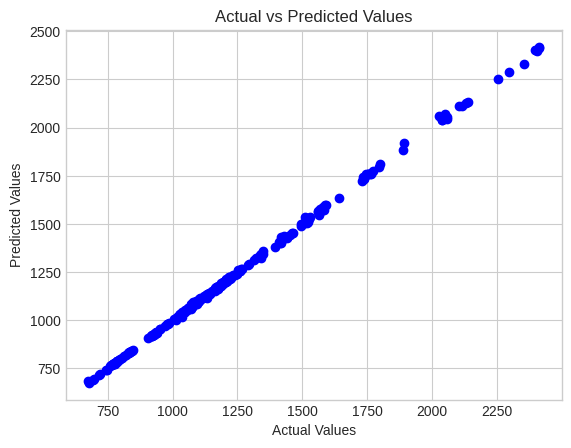

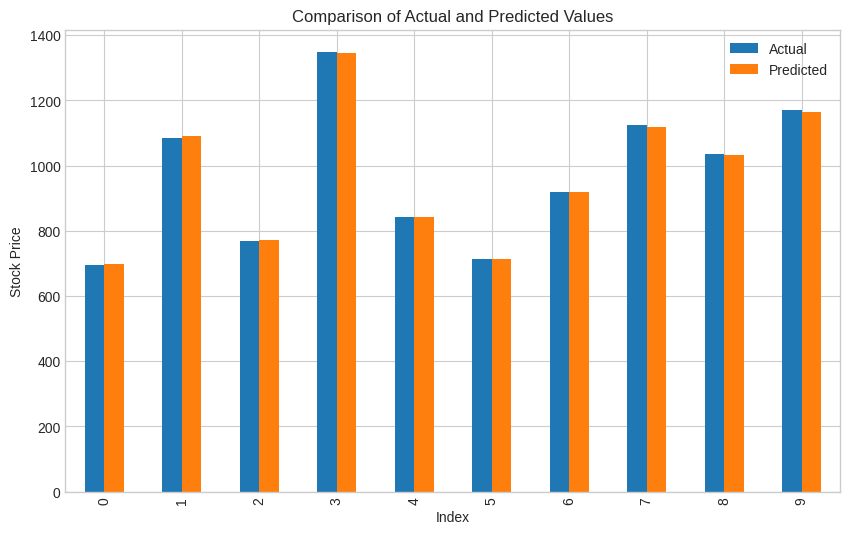

In [ ]:
# Calculate model accuracy
accuracy = 100 - np.mean(abs((y_test- y_pred) / y_test) * 100)
print(f"Model Accuracy: {accuracy:.2f}%")

# Scatter plot of actual vs predicted values
plt.scatter(df_results['Actual'], df_results ['Predicted'], color='blue')
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

# Bar chart for the first 10 predictions
df_results.head(10).plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of Actual and Predicted Values")
plt.xlabel("Index")
plt.ylabel("Stock Price")
plt.show()

In [ ]:

open_price = float(input("Enter the Open price: "))
high_price = float(input("Enter the High price: "))
low_price = float(input("Enter the Low price: "))
volume = float(input("Enter the Volume: "))

# Create a new data point with the user's input
new_data = np.array([[open_price, high_price, low_price, volume]])

# Use the trained regressor to predict the 'Close' price
predicted_price = regressor.predict(new_data)

# Display the predicted price
print(f"Predicted Close Price: {predicted_price[0]:.2f}")

Enter the Open price: 180
Enter the High price: 195
Enter the Low price: 170
Enter the Volume: 4000
Predicted Close Price: 185.28
